In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

## Configuration

Add entries to `runs` for each simulation you want to compare.
Each entry is a dict with:
- `path`: directory containing the output `.txt` files
- `label`: legend label
- `color`: matplotlib color (or `None` to auto-pick)

Set `Zn` to the symmetry order of the model (3 for Z3, 4 for Z4, …).
The number of distinct wall-type scaling columns in `average_energies.txt` is `Zn // 2`
(Z3 → 1, Z4 → 2, Z5 → 2, Z6 → 3, …).
Leave `Zn = None` to auto-detect.

In [2]:
base = "/mt/user-batch/dpasari/scan_alt_tests/"

# Parameter grids — (directory_tag, numeric_value)
beta_tags = [("0p1", 0.1),  ("1", 1.0)]
# beta_tags = [ ("2", 2.0)]
H_tags    = [ ("0p3mu", 0.3), ("1mu", 1.0)]
# H_tags    = [("0p3mu", 0.3), ("1mu", 1.0), ("3mu", 3.0)]
k_vals    = [ 3]
# k_vals    = [5]

# One colour per beta value (tab10 gives 10 distinct colours)
beta_colors = plt.cm.tab10(np.linspace(0, 0.59, len(beta_tags)))

runs = []
for (b_str, b_val), color in zip(beta_tags, beta_colors):
    for H_str, H_val in H_tags:
        for k in k_vals:
            dirname = f"results_z3_b{b_str}_H{H_str}_k{k}_alt_tests"
            runs.append({
                "path":  base + dirname + "/",
                "label": rf"$\beta={b_val},\;H={H_val}\mu,\;k={k}$",
                "color": color,
                # extra fields for filtering / grouping in plot cells
                "beta":  b_val,
                "H":     H_val,
                "k":     k,
            })

Zn = 3   # Z3 symmetry

# Physics / lattice parameters used in derived quantities
lside   = 100
N_lat   = 512
mu      = 0.0547723
lambda1 = 0.003
lambda2 = 0.0516398
beta_phys = lambda2 * 3 / (8 * lambda1) ** 0.5
g_beta    = 3.62 - 2.12 / (1 + 1.85 * beta_phys ** 1.81)
vev       = mu / (2 * lambda1) ** 0.5 * (beta_phys + (1 + beta_phys ** 2))
m_a       = np.sqrt((9 / np.sqrt(2)) * lambda2 * mu * vev)
del_dw    = g_beta / m_a
print(f"beta_phys = {beta_phys:.4f},  del_dw = {del_dw:.4f}")
print(f"Total runs configured: {len(runs)}")

beta_phys = 1.0000,  del_dw = 14.7187
Total runs configured: 4


## Loader functions

In [3]:
def load_energies(path, zn=None):
    """
    Load average_energies.txt.
    Fixed columns: eta, Ek_1, Ek_2, Eg_1, Eg_2, Ev_1, Ev_2, Ev_3, E_tot  (9 columns)
    Remaining columns are wall-type scalings: Zn // 2 distinct wall types
    (Z3 -> 1, Z4 -> 2, Z5 -> 2, Z6 -> 3, ...).
    If zn is given the expected number of scaling cols is zn//2; otherwise auto-detected.
    Returns a dict.
    """
    file_path = path + "average_energies.txt"
    rows = []
    try:
        with open(file_path) as f:
            for line in f:
                cols = line.split()
                if cols:
                    rows.append([float(c) for c in cols])
    except FileNotFoundError:
        print(f"[load_energies] File not found: {file_path}")
        return None

    if not rows:
        print(f"[load_energies] Empty file: {file_path}")
        return None

    data = np.array(rows)
    n_scal = data.shape[1] - 9   # columns after the fixed 9
    if zn is not None and n_scal != zn // 2:
        print(f"[load_energies] Warning: expected {zn // 2} scaling cols for Z{zn}, "
              f"found {n_scal} in {file_path}")

    return {
        "eta":          data[:, 0],
        "Ek_1":         data[:, 1],
        "Ek_2":         data[:, 2],
        "Eg_1":         data[:, 3],
        "Eg_2":         data[:, 4],
        "Ev_1":         data[:, 5],
        "Ev_2":         data[:, 6],
        "Ev_3":         data[:, 7],
        "E_tot":        data[:, 8],
        "scal":         [data[:, 9 + i] for i in range(n_scal)],  # one array per distinct wall type
        "n_wall_types": n_scal,
    }


def load_scalar(path, idx):
    """
    Load average_scalar_{idx}.txt.
    Columns: eta, phi, phi_prime, phi2, phi_prime2, rms_phi, rms_phi_prime
    """
    file_path = path + f"average_scalar_{idx}.txt"
    rows = []
    try:
        with open(file_path) as f:
            for line in f:
                cols = line.split()
                if len(cols) == 7:
                    rows.append([float(c) for c in cols])
    except FileNotFoundError:
        print(f"[load_scalar] File not found: {file_path}")
        return None

    if not rows:
        return None

    data = np.array(rows)
    return {
        "eta":           data[:, 0],
        "phi":           data[:, 1],
        "phi_prime":     data[:, 2],
        "phi2":          data[:, 3],
        "phi_prime2":    data[:, 4],
        "rms_phi":       data[:, 5],
        "rms_phi_prime": data[:, 6],
    }


def load_scale_factor(path):
    """
    Load average_scale_factor.txt.
    Columns: eta, a, adot, H
    """
    file_path = path + "average_scale_factor.txt"
    rows = []
    try:
        with open(file_path) as f:
            for line in f:
                cols = line.split()
                if len(cols) == 4:
                    rows.append([float(c) for c in cols])
    except FileNotFoundError:
        print(f"[load_scale_factor] File not found: {file_path}")
        return None

    if not rows:
        return None

    data = np.array(rows)
    return {
        "eta":  data[:, 0],
        "a":    data[:, 1],
        "adot": data[:, 2],
        "H":    data[:, 3],
    }


# colour cycle fallback
DEFAULT_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]

## Load all runs

In [4]:
import os

datasets = []
skipped  = []

for i, run in enumerate(runs):
    if not os.path.isdir(run["path"]):
        skipped.append(run["label"])
        continue

    color = run["color"] if run.get("color") is not None else DEFAULT_COLORS[i % len(DEFAULT_COLORS)]
    d = {
        "label":        run["label"],
        "color":        color,
        "beta":         run.get("beta"),
        "H":            run.get("H"),
        "k":            run.get("k"),
        "energies":     load_energies(run["path"], zn=Zn),
        "scalar_0":     load_scalar(run["path"], 0),
        "scalar_1":     load_scalar(run["path"], 1),
        "scale_factor": load_scale_factor(run["path"]),
    }
    datasets.append(d)
    status = {k: ("OK" if v is not None else "MISSING") for k, v in d.items()
              if k not in ("label", "color", "beta", "H", "k")}
    print(f"{run['label']:40s}  {status}")

print(f"\nLoaded: {len(datasets)}   Skipped (not ready): {len(skipped)}")

$\beta=0.1,\;H=0.3\mu,\;k=3$              {'energies': 'OK', 'scalar_0': 'OK', 'scalar_1': 'OK', 'scale_factor': 'OK'}
$\beta=0.1,\;H=1.0\mu,\;k=3$              {'energies': 'OK', 'scalar_0': 'OK', 'scalar_1': 'OK', 'scale_factor': 'OK'}
$\beta=1.0,\;H=0.3\mu,\;k=3$              {'energies': 'OK', 'scalar_0': 'OK', 'scalar_1': 'OK', 'scale_factor': 'OK'}
$\beta=1.0,\;H=1.0\mu,\;k=3$              {'energies': 'OK', 'scalar_0': 'OK', 'scalar_1': 'OK', 'scale_factor': 'OK'}

Loaded: 4   Skipped (not ready): 0


## Plot helper

In [5]:
def styled_ax(ax, xlabel=r"$\eta$", ylabel="", title="", legend=True):
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True, labelsize=11)
    ax.grid(True, linestyle="--", linewidth=0.5)
    if title:
        ax.set_title(title, fontsize=13)
    if legend:
        ax.legend(fontsize=11)

In [6]:
# ── Paper style ────────────────────────────────────────────────────────────
from matplotlib import rc

rc('text', usetex=True)
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica'],
              'weight': 'bold', 'size': 16})

# Colour palette — one entry per beta value
beta_palette = {
    0.01: '#440154',
    0.05: '#31688E',
    0.1:  '#35B779',
    0.3:  '#F8961E',
    1.0:  '#B12A90',
    2.0:  '#E76254',
}

def paper_ax(ax, xlabel=r"$\eta$", ylabel="", title=""):
    ax.set_xlabel(xlabel, fontsize=34)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=34)
    if title:
        ax.set_title(title, fontsize=28)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.tick_params(axis='both', which='both', direction='in', labelsize=28, pad=10)
    ax.tick_params(which='major', length=14)
    ax.tick_params(which='minor', length=7)
    ax.minorticks_on()

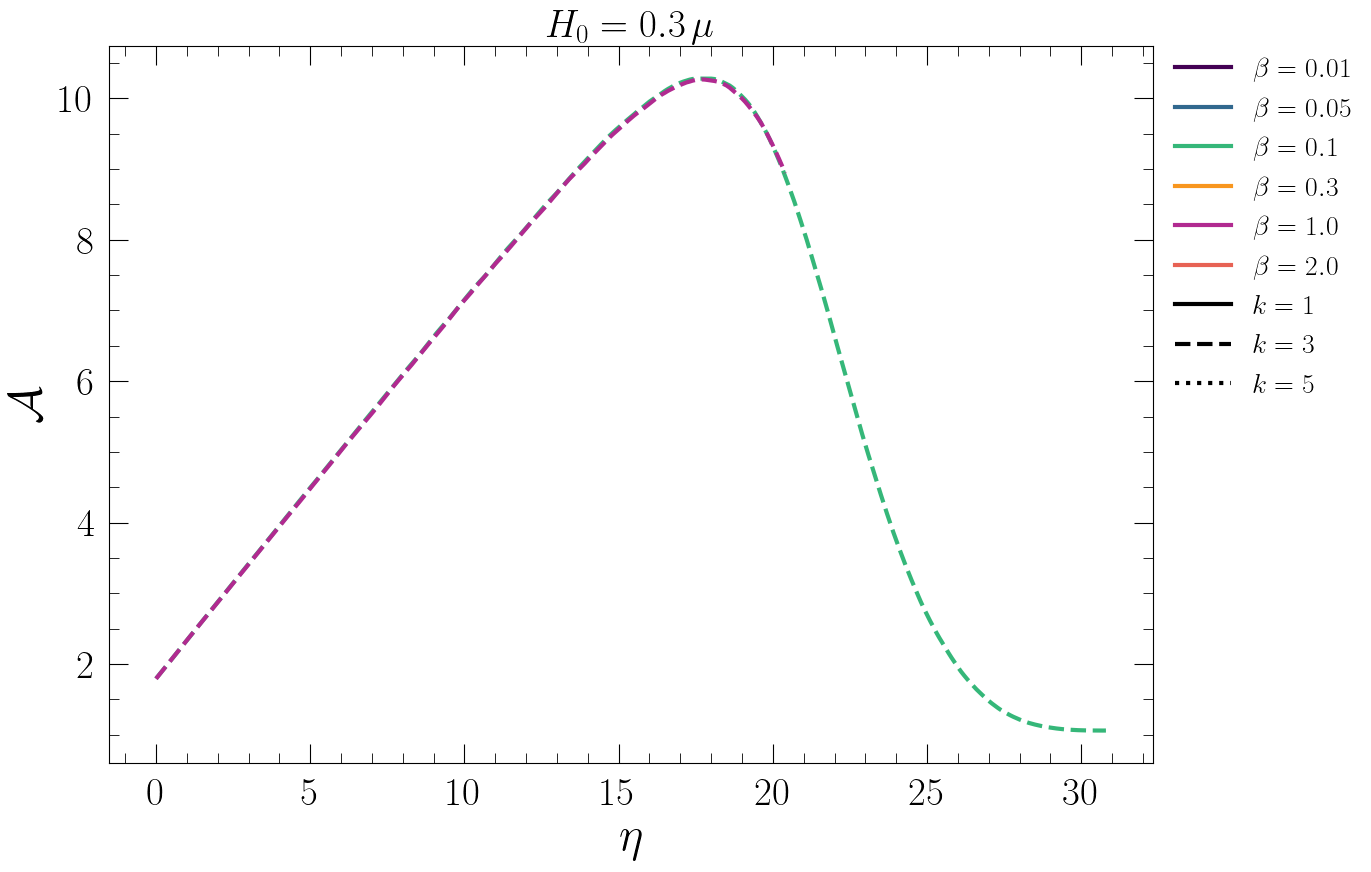

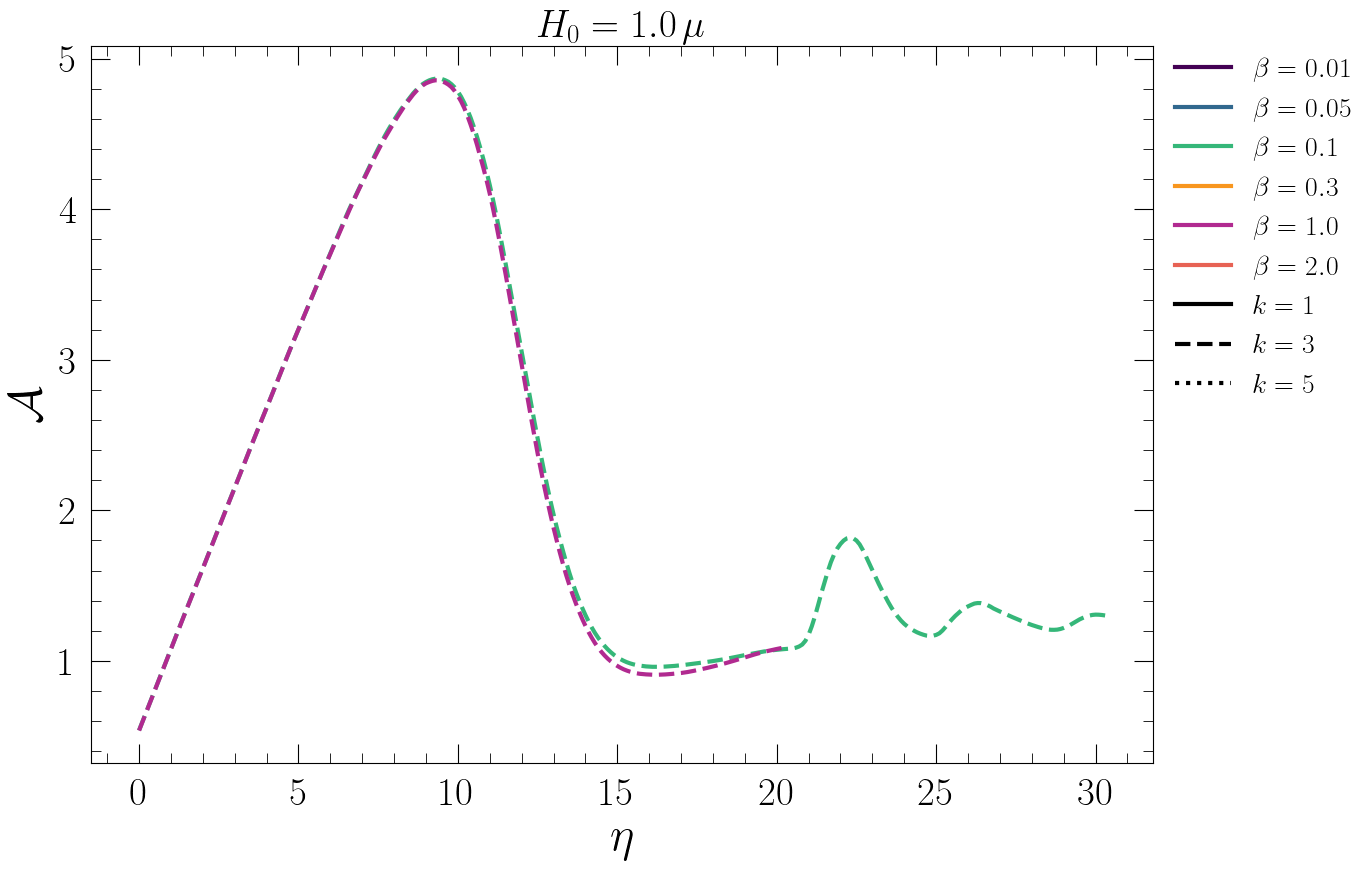

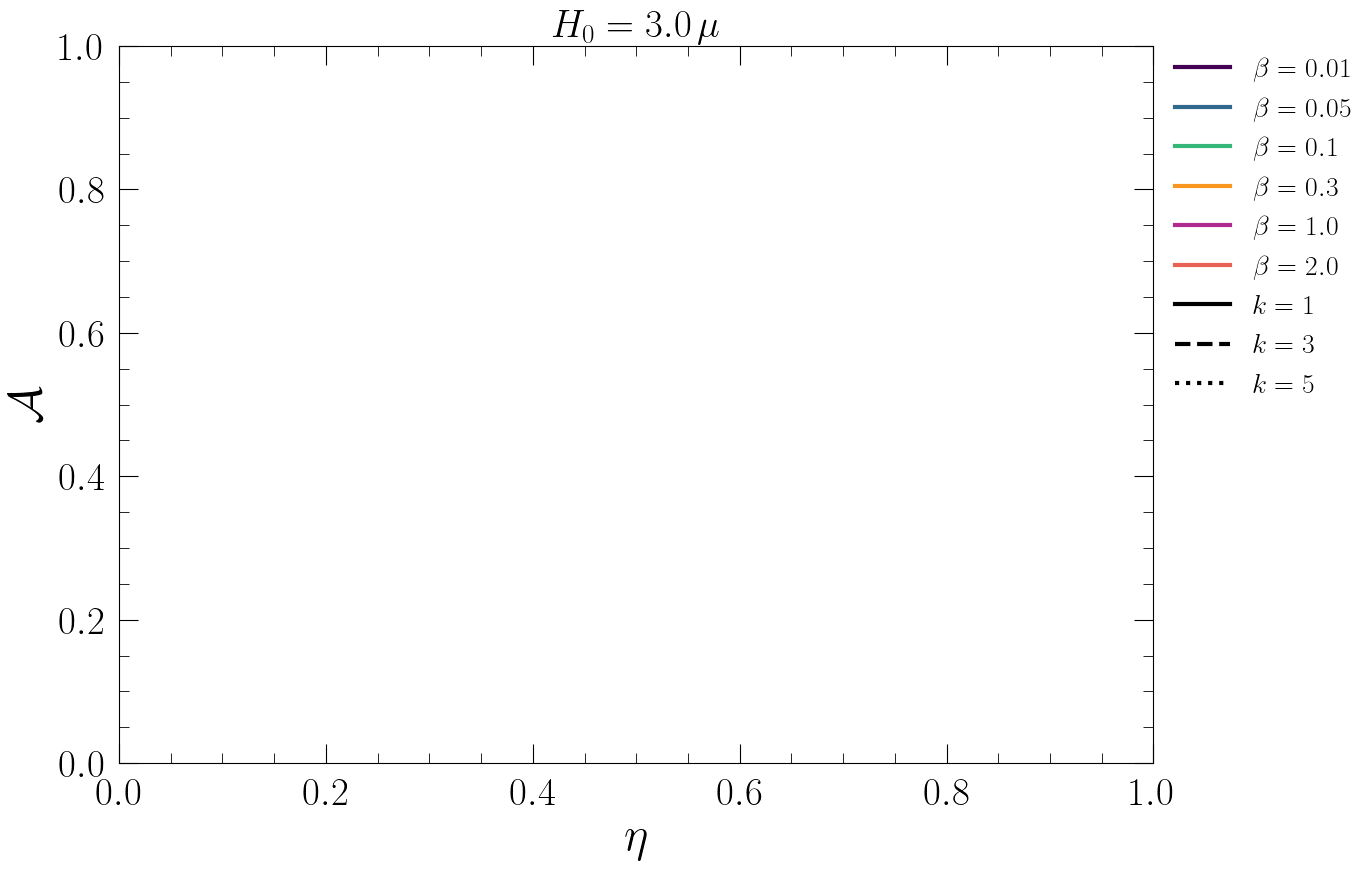

In [7]:
# ── Vary k at fixed H ─────────────────────────────────────────────────────
# One separate figure per H value.
# Colour encodes beta; linestyle encodes k.
# ──────────────────────────────────────────────────────────────────────────

H_panels   = [0.3, 1.0, 3.0]
betas_show = [0.01,0.05,0.1,0.3, 1.0, 2.0]           # ← edit to choose which betas to compare

k_ls = {1: 'solid', 3: 'dashed', 5: 'dotted'}

legend_elems = (
    [Line2D([0],[0], color=beta_palette[b], lw=3, label=rf"$\beta = {b}$")
     for b in betas_show if b in beta_palette]
  + [Line2D([0],[0], color='k', lw=3, linestyle=ls, label=rf"$k = {k}$")
     for k, ls in k_ls.items()]
)

for H_fix in H_panels:
    fig, ax = plt.subplots(figsize=(14, 9))
    sub = [d for d in datasets
           if d["H"] == H_fix and d["beta"] in betas_show
           and d["energies"] is not None and d["scale_factor"] is not None]
    for d in sub:
        en = d["energies"]
        sf = d["scale_factor"]
        n  = min(len(en["eta"]) - 1, len(sf["a"]) - 1)
        A  = en["scal"][0][:n] / (2 * sf["a"][:n] * sf["H"][:n])
        ax.plot(en["eta"][:n], A,
                color=beta_palette[d["beta"]],
                linestyle=k_ls[d["k"]],
                linewidth=3)
    paper_ax(ax, ylabel=r"$\mathcal{A}$", title=rf"$H_0 = {H_fix}\,\mu$")
    ax.legend(handles=legend_elems, fontsize=20, frameon=False,
          loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
    plt.tight_layout()
    plt.savefig(f"wall_area_vary_k_H{str(H_fix).replace('.','p')}mu.pdf", bbox_inches='tight')
    plt.show()

From second derivative of potential at the vacuum, I can show:

$$\tilde{m}_a^2 = \frac{m_a^2}{\mu^2} = 6\beta\left(\beta + \sqrt{\beta^2+1}\right)$$

DW width in program units (independent of the specific μ, λ₁, λ₂ — only β matters):

$$\tilde{\delta} = \frac{g(\beta)}{\tilde{m}_a}, \quad g(\beta) = 3.62 - \frac{2.12}{1 + 1.85,\beta^{1.81}}$$

A static domain wall in FRW satisfies the same profile equation as in flat space (in physical coordinates):

$$\nabla^2_{\text{phys}} \phi = \partial V/\partial \phi$$

So the physical width $\delta_{\text{phys}} = g(\beta)/m_a$ is constant. But in comoving program units:

$$\tilde{\delta}_{\text{com}}(\tau) = \frac{g(\beta)}{\tilde{m}_a \cdot a(\tau)} = \frac{\tilde{\delta}_0}{1 + \tilde{H}_0,\tau}$$

Grid points per DW at time τ:

$$N_{\text{res}}(\tau) = \frac{\tilde{\delta}_{\text{com}}(\tau)}{\Delta\tilde{x}} = \frac{N \cdot g(\beta)}{\tilde{m}_a \cdot L \cdot (1 + \tilde{H}_0,\tau)}$$

The constraint must hold at τ_end, not τ=0. My earlier table was wrong — it only applied the constraint at τ=0.

$$N_{\text{res}}(\tau) = \frac{512 \times 1.914}{0.814 \times 100 \times (1 + \tilde{H}_0,\tau)} = \frac{12.05}{1 + \tilde{H}_0,\tau}$$

3. Optimal Parameters for the Full Scan
Key quantities:

β	m̃_a	δ̃	C_res = N·δ̃
0.01	0.246	6.097	3122
0.05	0.562	2.702	1383
0.10	0.814	1.915	980
0.30	1.555	1.200	615
1.00	3.806	0.756	387
2.00	7.130	0.468	240
C_res = N·δ̃ is the resolution budget — the maximum value of lSide×a_end that keeps N_res≥1.

Scaling onset (when A settles): $a_{\rm scale} \approx 12,\tilde{H}_0/\tilde{m}_a$ for $\tilde{H}_0 \geq \tilde{m}a$, else $a{\rm scale} \approx 12$ (empirically from the H=1μ data showing A constant by η≈12-15).

Optimal lSide = min(resolution limit, box-size limit):

$$L_{\rm opt} = \min!\left(\frac{C_{\rm res}}{a_{\rm scale}},; \frac{3,a_{\rm scale}}{\tilde{H}0}\right), \qquad \tau{\rm end} = \frac{a_{\rm scale}-1}{\tilde{H}_0}$$

Computed values (N_res at end ≈ 1, Box/R_H ≈ 3 where achievable):

β	H=0.05μ	H=0.3μ	H=1.0μ	H=3.0μ
0.01	L=260, t=220	L=146, t=45	L=64, t=48	L=21, t=48
0.05	L=115, t=220	L=115, t=37	L=64, t=20	L=22, t=21
0.10	L=82, t=220	L=82, t=37	L=44, t=14	L=22, t=14
0.30	L=51, t=220	L=51, t=37	L=36, t=11	L=23, t=7
1.00	L=32, t=220	L=32, t=37	L=32, t=11	L=12, t=4
2.00	L=20, t=220	L=20, t=37	L=20, t=11	L=12, t=4
H=0.05μ is fundamentally compromised: the Hubble radius at a_scale=12 is R_H=12/0.05=240, larger than any feasible lSide with N=512. You can't get even 1 Hubble patch and proper resolution simultaneously. This explains why it doesn't show scaling — not enough volume. H=0.3μ and above are the physically meaningful cases.

Compared to your current lSide=100, tMax=50: This over-resolves at the start and runs past the useful window for the high-H runs. The existing runs aren't wrong (A measurement is valid from thin-wall tracking), but to maximize patches while maintaining resolution from first principles, the smaller lSide values above are optimal.

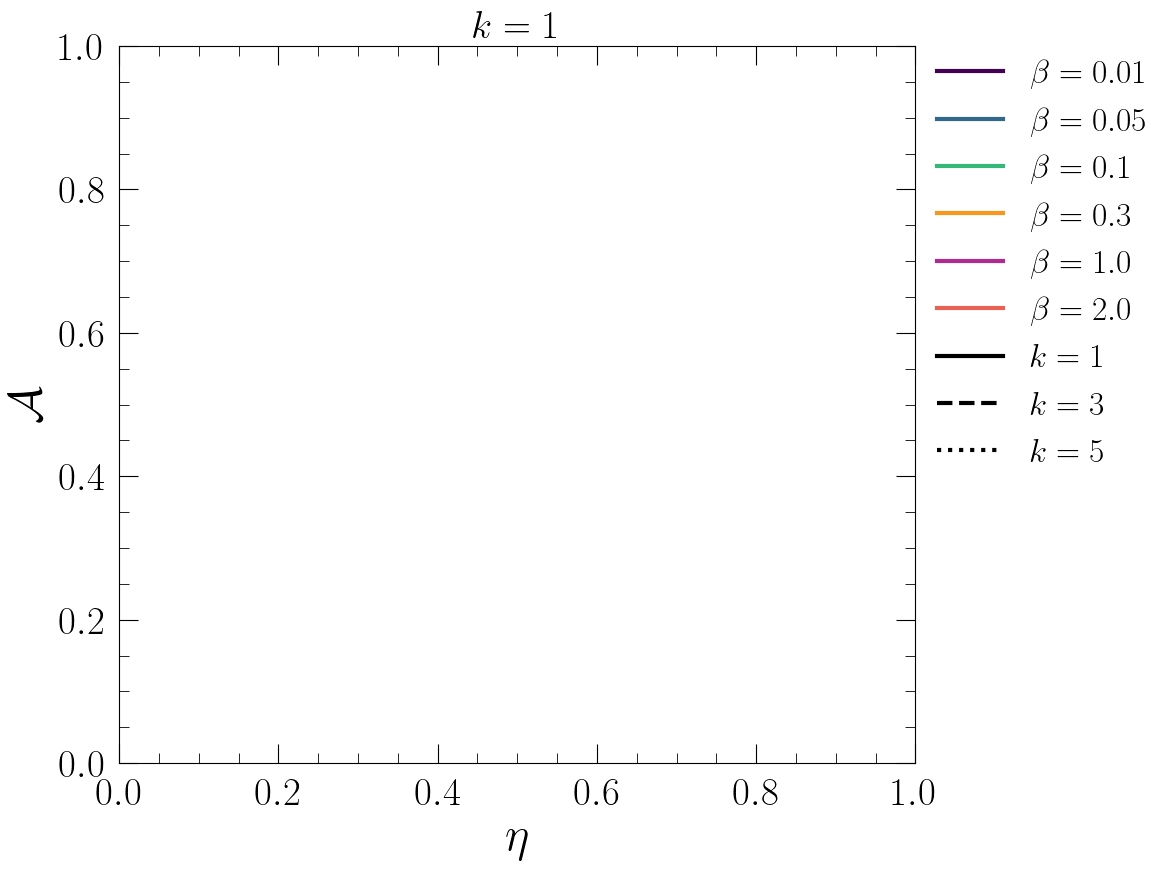

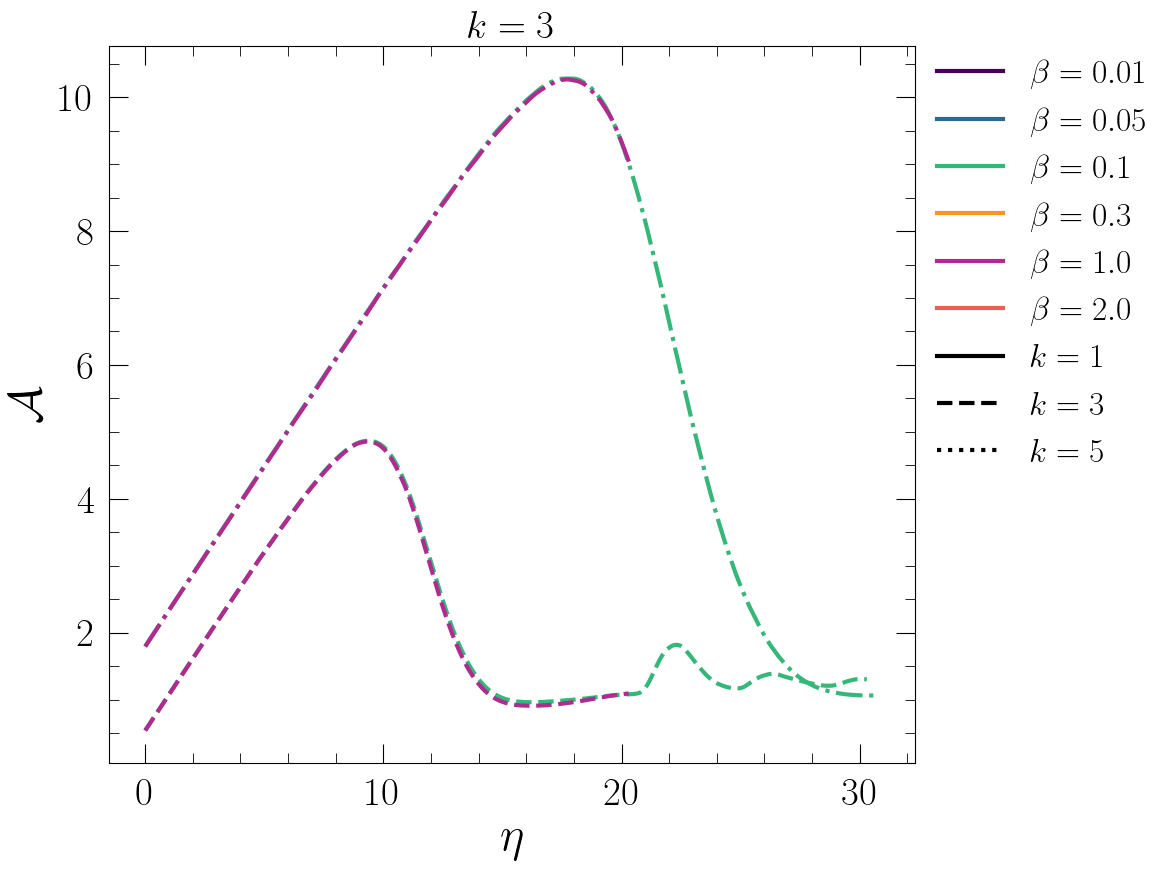

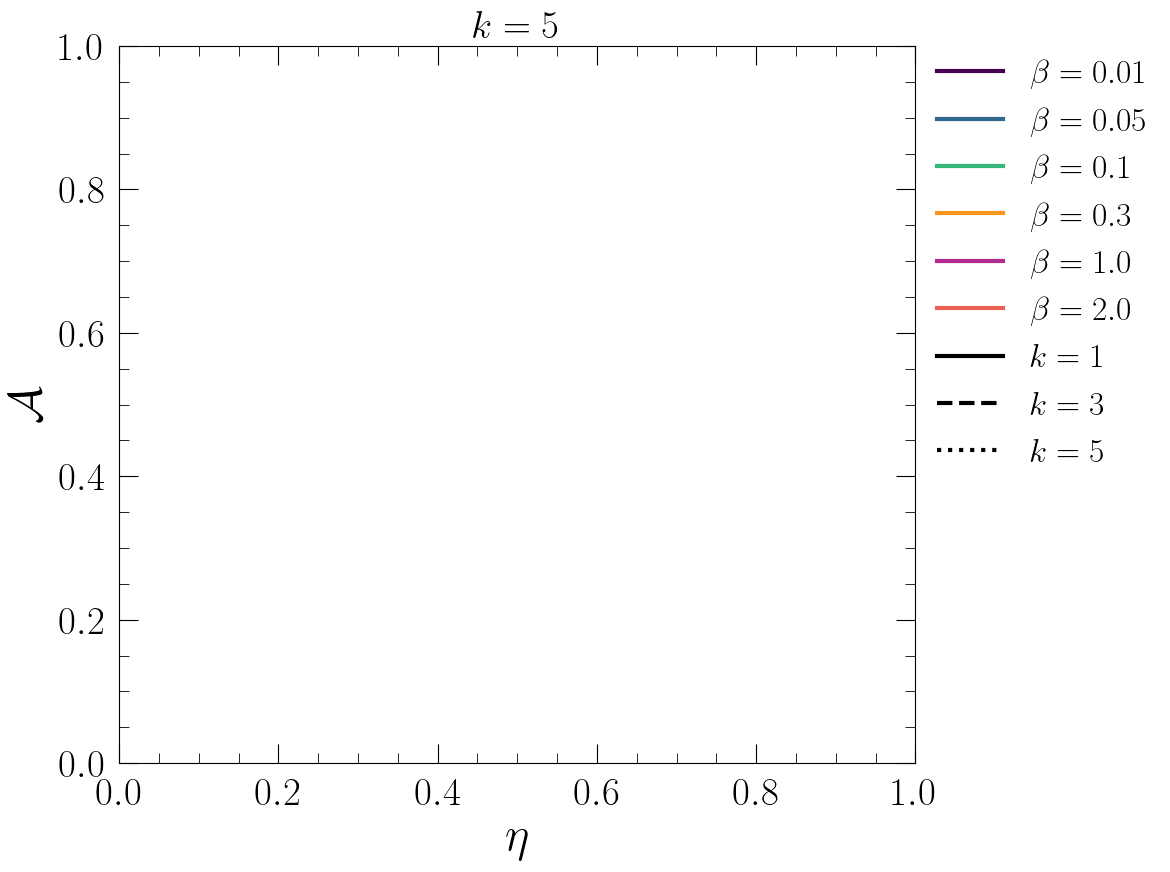

In [8]:
# ── Vary H at fixed k ─────────────────────────────────────────────────────
# One separate figure per k value.
# Colour encodes beta; linestyle encodes H.
# ──────────────────────────────────────────────────────────────────────────

k_panels    = [1, 3, 5]
betas_show2 = [0.1, 1.0, 2.0]          # ← edit to taste

H_ls = {0.05: 'dotted', 0.3: 'dashdot', 1.0: 'dashed', 3.0: 'solid'}

legend_elems2 = (
    [Line2D([0],[0], color=beta_palette[b], lw=3, label=rf"$\beta = {b}$")
     for b in betas_show2 if b in beta_palette]
  + [Line2D([0],[0], color='k', lw=3, linestyle=ls, label=rf"$H_0 = {H}\,\mu$")
     for H, ls in H_ls.items()]
)

for k_fix in k_panels:
    fig, ax = plt.subplots(figsize=(12, 9))
    sub = [d for d in datasets
           if d["k"] == k_fix and d["beta"] in betas_show2
           and d["energies"] is not None and d["scale_factor"] is not None]
    for d in sub:
        en = d["energies"]
        sf = d["scale_factor"]
        n  = min(len(en["eta"]) - 1, len(sf["a"]) - 1)
        A  = en["scal"][0][:n] / (2 * sf["a"][:n] * sf["H"][:n])
        ax.plot(en["eta"][:n], A,
                color=beta_palette[d["beta"]],
                linestyle=H_ls[d["H"]],
                linewidth=3)
    paper_ax(ax, ylabel=r"$\mathcal{A}$", title=rf"$k = {k_fix}$")
    ax.legend(handles=legend_elems, fontsize=24, frameon=False,
          loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)

    plt.tight_layout()
    plt.savefig(f"wall_area_vary_H_k{k_fix}.pdf", bbox_inches='tight')
    plt.show()

## Wall area scaling  A = scal / (2 a H)

Each wall type is plotted with a different linestyle; runs are distinguished by colour.

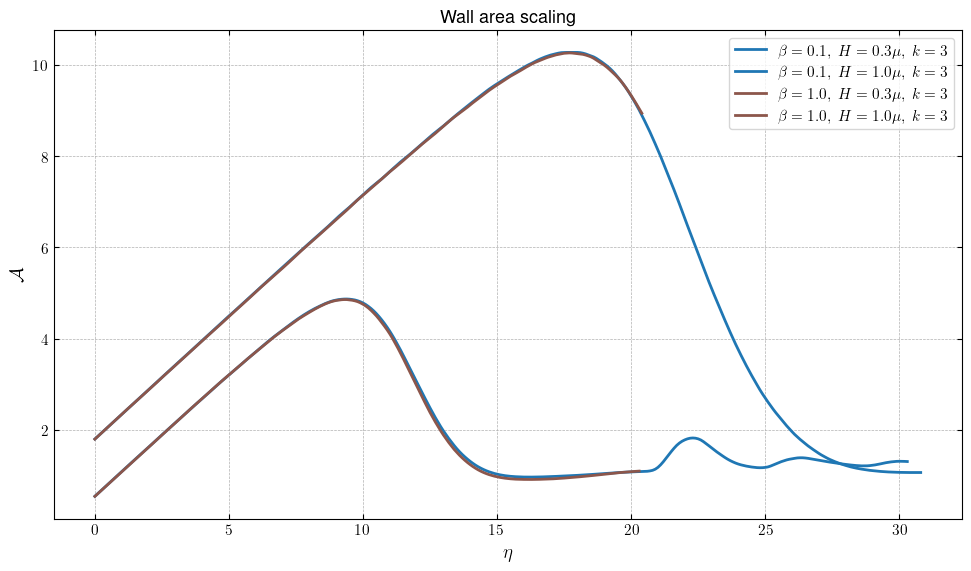

In [9]:
linestyles = ["-", "--", "-.", ":"]

fig, ax = plt.subplots(figsize=(10, 6))

for d in datasets:
    en = d["energies"]
    sf = d["scale_factor"]
    if en is None or sf is None:
        continue

    # align lengths (energies and scale_factor may differ by 1 row)
    n = min(len(en["eta"]) - 1, len(sf["a"]) - 1)   # -1 to match original [:-1] indexing
    a = sf["a"][:n]
    H = sf["H"][:n]

    for j, scal_j in enumerate(en["scal"]):
        wall_label = f"{d['label']} wall {j+1}" if en["n_wall_types"] > 1 else d["label"]
        ls = linestyles[j % len(linestyles)]
        ax.plot(en["eta"][:n], scal_j[:n] / 2 / a / H,
                color=d["color"], linestyle=ls, linewidth=2, label=wall_label)

styled_ax(ax, ylabel=r"$\mathcal{A}$", title="Wall area scaling")
plt.tight_layout()
plt.show()

## Total energy

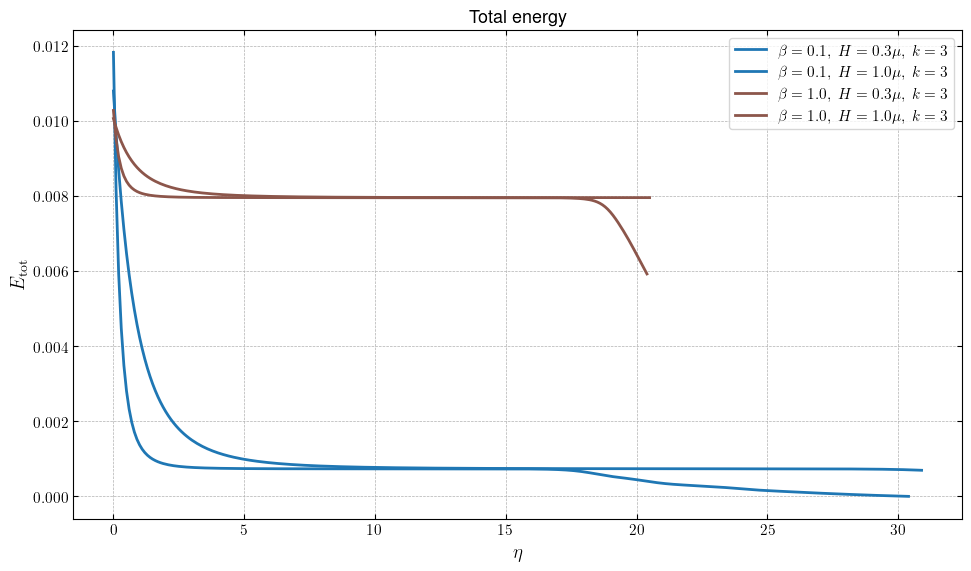

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

for d in datasets:
    en = d["energies"]
    if en is None:
        continue
    ax.plot(en["eta"], en["E_tot"], color=d["color"], linewidth=2, label=d["label"])

styled_ax(ax, ylabel=r"$E_{\rm tot}$", title="Total energy")
plt.tight_layout()
plt.show()

## Kinetic energies

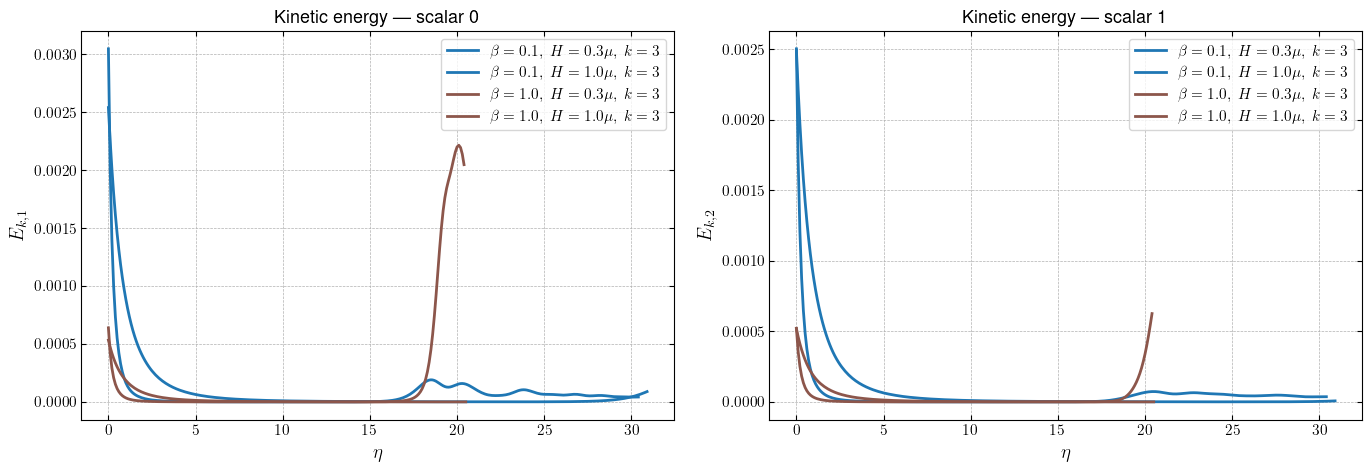

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for d in datasets:
    en = d["energies"]
    if en is None:
        continue
    axes[0].plot(en["eta"], en["Ek_1"], color=d["color"], linewidth=2, label=d["label"])
    axes[1].plot(en["eta"], en["Ek_2"], color=d["color"], linewidth=2, label=d["label"])

styled_ax(axes[0], ylabel=r"$E_{k,1}$", title="Kinetic energy — scalar 0")
styled_ax(axes[1], ylabel=r"$E_{k,2}$", title="Kinetic energy — scalar 1")
plt.tight_layout()
plt.show()

## Gradient energies

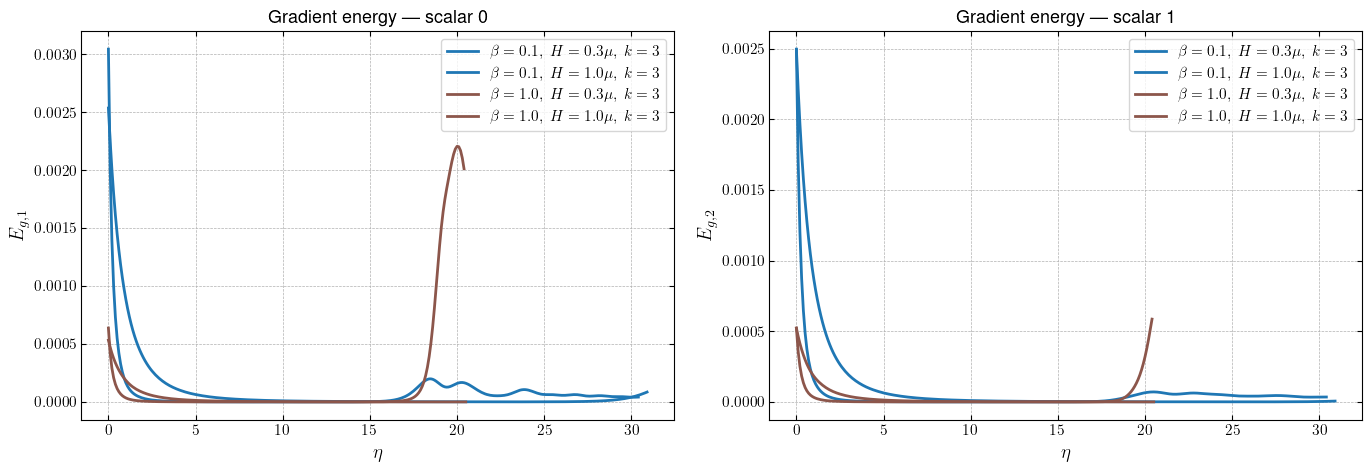

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for d in datasets:
    en = d["energies"]
    if en is None:
        continue
    axes[0].plot(en["eta"], en["Eg_1"], color=d["color"], linewidth=2, label=d["label"])
    axes[1].plot(en["eta"], en["Eg_2"], color=d["color"], linewidth=2, label=d["label"])

styled_ax(axes[0], ylabel=r"$E_{g,1}$", title="Gradient energy — scalar 0")
styled_ax(axes[1], ylabel=r"$E_{g,2}$", title="Gradient energy — scalar 1")
plt.tight_layout()
plt.show()

## Potential energies

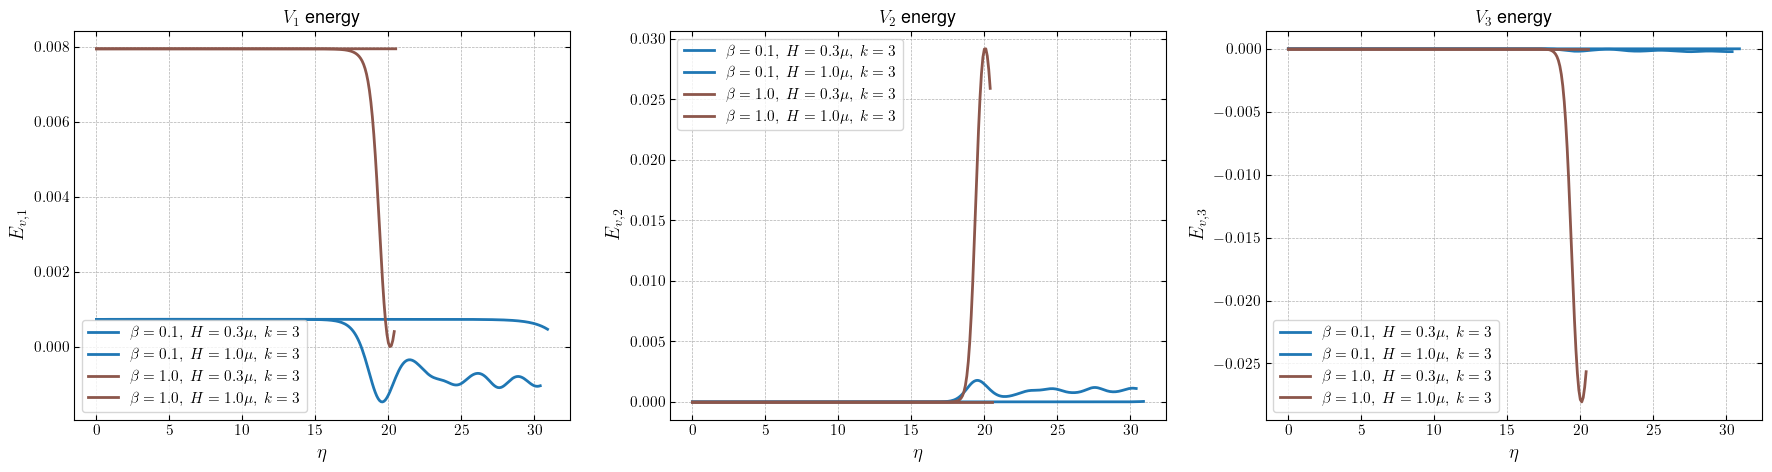

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for d in datasets:
    en = d["energies"]
    if en is None:
        continue
    axes[0].plot(en["eta"], en["Ev_1"], color=d["color"], linewidth=2, label=d["label"])
    axes[1].plot(en["eta"], en["Ev_2"], color=d["color"], linewidth=2, label=d["label"])
    axes[2].plot(en["eta"], en["Ev_3"], color=d["color"], linewidth=2, label=d["label"])

styled_ax(axes[0], ylabel=r"$E_{v,1}$", title=r"$V_1$ energy")
styled_ax(axes[1], ylabel=r"$E_{v,2}$", title=r"$V_2$ energy")
styled_ax(axes[2], ylabel=r"$E_{v,3}$", title=r"$V_3$ energy")
plt.tight_layout()
plt.show()

## Scale factor & Hubble rate

In [14]:
3/10

0.3

In [15]:
choice = 20
datasets[0]["scale_factor"]["a"][choice],datasets[0]["scale_factor"]["eta"][choice],datasets[0]["scale_factor"]["H"][choice]

(np.float64(1.60000760040716), np.float64(2.0), np.float64(0.187503515690919))

In [16]:
datasets[1]["scale_factor"]["a"][choice],datasets[1]["scale_factor"]["eta"][choice],datasets[1]["scale_factor"]["H"][choice]

(np.float64(3.00006479411597), np.float64(2.0), np.float64(0.333344444814827))

In [17]:
datasets[2]["scale_factor"]["a"][choice],datasets[2]["scale_factor"]["eta"][choice],datasets[2]["scale_factor"]["H"][choice]

(np.float64(1.60000760040716), np.float64(2.0), np.float64(0.187503515690919))

IndexError: list index out of range

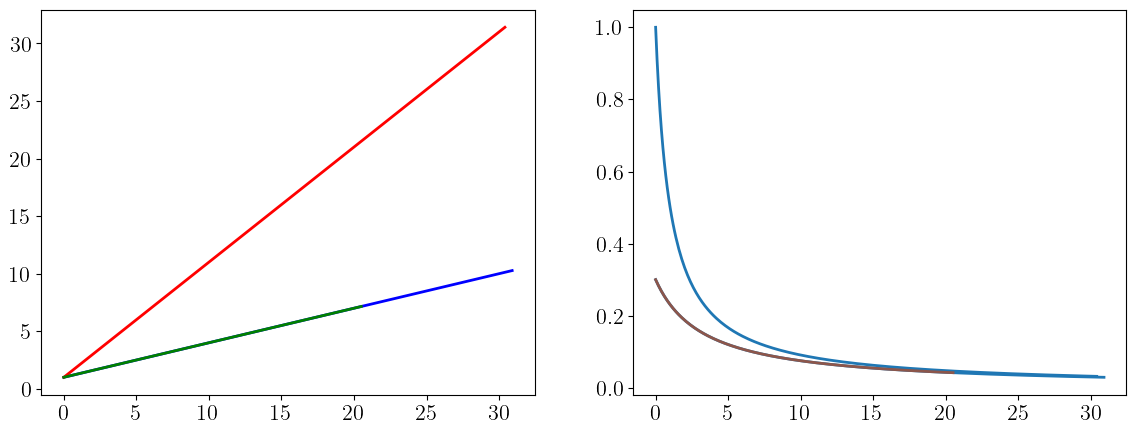

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colours = ["b","r","g"]

for j,d in enumerate(datasets):
    sf = d["scale_factor"]
    if sf is None:
        continue
    axes[0].plot(sf["eta"], sf["a"], color=colours[j], linewidth=2, label=d["label"])
    axes[1].plot(sf["eta"], sf["H"], color=d["color"], linewidth=2, label=d["label"])

styled_ax(axes[0], ylabel=r"$a$",  title="Scale factor")
styled_ax(axes[1], ylabel=r"$H$",  title="Hubble rate")
plt.tight_layout()
plt.show()

## Scalar field 0  — mean ± σ

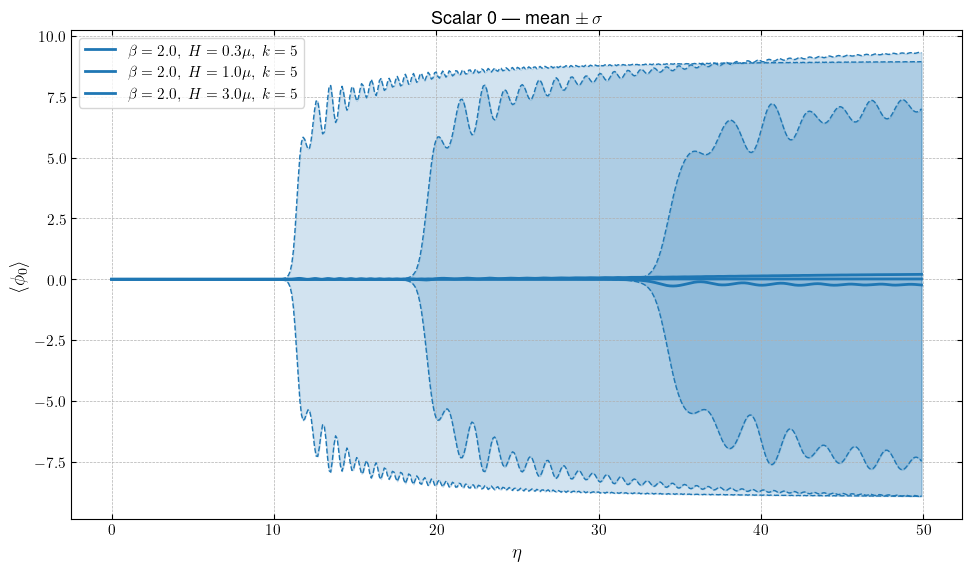

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for d in datasets:
    sc = d["scalar_0"]
    if sc is None:
        continue
    sigma = sc["phi2"] - sc["phi"] ** 2
    ax.fill_between(sc["eta"], sc["phi"] - sigma, sc["phi"] + sigma,
                    alpha=0.20, color=d["color"])
    ax.plot(sc["eta"], sc["phi"],         color=d["color"], linewidth=2, label=d["label"])
    ax.plot(sc["eta"], sc["phi"] - sigma, color=d["color"], linewidth=1, linestyle="--")
    ax.plot(sc["eta"], sc["phi"] + sigma, color=d["color"], linewidth=1, linestyle="--")

styled_ax(ax, ylabel=r"$\langle\phi_0\rangle$", title=r"Scalar 0 — mean $\pm\,\sigma$")
plt.tight_layout()
plt.show()

## Scalar field 1  — mean ± σ

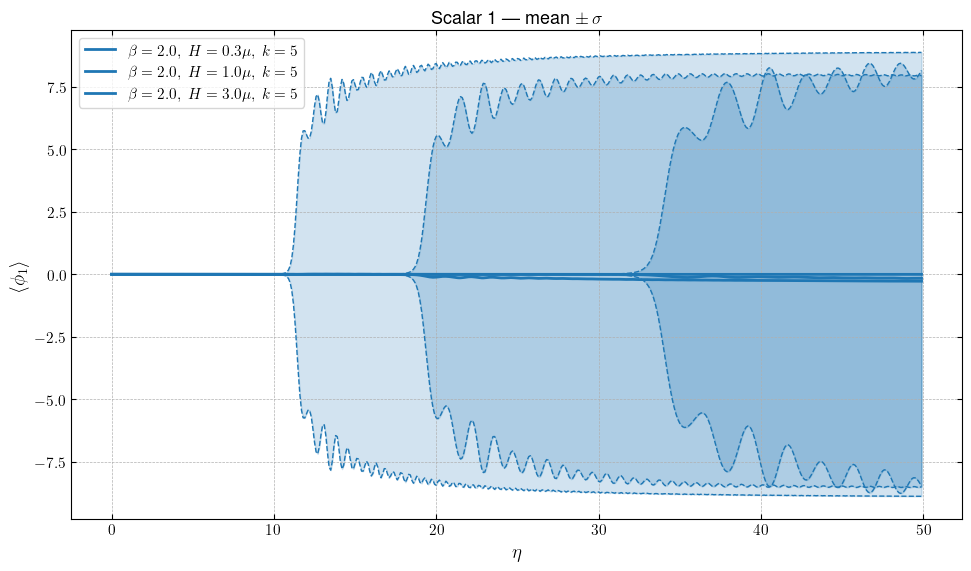

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for d in datasets:
    sc = d["scalar_1"]
    if sc is None:
        continue
    sigma = sc["phi2"] - sc["phi"] ** 2
    ax.fill_between(sc["eta"], sc["phi"] - sigma, sc["phi"] + sigma,
                    alpha=0.20, color=d["color"])
    ax.plot(sc["eta"], sc["phi"],         color=d["color"], linewidth=2, label=d["label"])
    ax.plot(sc["eta"], sc["phi"] - sigma, color=d["color"], linewidth=1, linestyle="--")
    ax.plot(sc["eta"], sc["phi"] + sigma, color=d["color"], linewidth=1, linestyle="--")

styled_ax(ax, ylabel=r"$\langle\phi_1\rangle$", title=r"Scalar 1 — mean $\pm\,\sigma$")
plt.tight_layout()
plt.show()

## Regime validity check

Checks when `3/H > lside` (horizon smaller than box) and when `lside/N_lat > del_dw/a` (wall resolved).

In [ ]:
for d in datasets:
    sf = d["scale_factor"]
    if sf is None:
        continue
    eta_arr = sf["eta"]
    a_arr   = sf["a"]
    H_arr   = sf["H"]

    mask_hor = 3 / H_arr > lside
    mask_res = lside / N_lat > del_dw / a_arr

    eta_hor = eta_arr[mask_hor] if mask_hor.any() else np.array([])
    eta_res = eta_arr[mask_res] if mask_res.any() else np.array([])

    print(f"{d['label']}")
    print(f"  horizon > box  from eta = {eta_hor[0]:.3f}" if len(eta_hor) else "  horizon never exceeds box")
    print(f"  wall resolved  until eta = {eta_res[0]:.3f}" if len(eta_res) else "  wall never not resolved")
    print()

$\beta=2.0,\;H=0.3\mu,\;k=5$
  horizon > box  from eta = 30.100
  wall never not resolved

$\beta=2.0,\;H=1.0\mu,\;k=5$
  horizon > box  from eta = 32.400
  wall never not resolved

$\beta=2.0,\;H=3.0\mu,\;k=5$
  horizon > box  from eta = 33.100
  wall resolved  until eta = 24.800



## Energy breakdown — clean grid

All eight components on one 2×4 grid; one curve per run.
Colour = $\beta$, linestyle = $H_0$.


In [ ]:
# Style maps for the 4 Z3 runs
beta_color_z3 = {0.1: '#35B779', 1.0: '#B12A90', 0.01: '#440154',
                 0.05: '#31688E', 0.3: '#F8961E', 2.0: '#E76254'}
H_ls_z3 = {0.3: 'dashed', 1.0: 'solid', 3.0: 'dashdot', 0.05: 'dotted'}

def z3_style(d):
    return dict(color=beta_color_z3.get(d['beta'], 'k'),
                linestyle=H_ls_z3.get(d['H'], 'solid'),
                linewidth=2.2)

components = [
    ('E_tot', r'$E_{\rm tot}$'),
    ('Ek_1',  r'$E_{k,1}$ (Re)'),
    ('Ek_2',  r'$E_{k,2}$ (Im)'),
    ('Eg_1',  r'$E_{g,1}$ (Re)'),
    ('Eg_2',  r'$E_{g,2}$ (Im)'),
    ('Ev_1',  r'$E_{v,1}$'),
    ('Ev_2',  r'$E_{v,2}$'),
    ('Ev_3',  r'$E_{v,3}$  (Z$_N$ breaking)'),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True)
for ax, (key, title) in zip(axes.flat, components):
    for d in datasets:
        en = d['energies']
        if en is None:
            continue
        ax.plot(en['eta'], en[key], **z3_style(d))
    ax.set_title(title, fontsize=18)
    ax.grid(True, ls='--', lw=0.4, alpha=0.6)
    ax.tick_params(direction='in', top=True, right=True, labelsize=12)
    ax.minorticks_on()
for ax in axes[-1]:
    ax.set_xlabel(r'$\eta$', fontsize=16)

# Combined legend
beta_h = [Line2D([0],[0], color=beta_color_z3[b], lw=3, label=rf'$\beta = {b}$')
          for b in sorted({d['beta'] for d in datasets})]
H_h    = [Line2D([0],[0], color='k', lw=2.5, linestyle=H_ls_z3[h],
                 label=rf'$H_0 = {h}\,\mu$')
          for h in sorted({d['H'] for d in datasets})]
fig.legend(handles=beta_h + H_h, fontsize=14, frameon=False,
           loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=len(beta_h)+len(H_h))
plt.tight_layout()
plt.savefig('Z3_energy_breakdown.pdf', bbox_inches='tight')
plt.show()


### Summed energy budget

$E_{\rm kin} = E_{k,1}+E_{k,2}$, $E_{\rm grad} = E_{g,1}+E_{g,2}$, $E_{\rm pot} = E_{v,1}+E_{v,2}+E_{v,3}$.


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), sharex=True)
groups = [
    ('E_tot', lambda en: en['E_tot'],                       r'$E_{\rm tot}$'),
    ('Ekin',  lambda en: en['Ek_1'] + en['Ek_2'],            r'$E_{\rm kin}$'),
    ('Egrad', lambda en: en['Eg_1'] + en['Eg_2'],            r'$E_{\rm grad}$'),
    ('Epot',  lambda en: en['Ev_1'] + en['Ev_2'] + en['Ev_3'], r'$E_{\rm pot}$'),
]
for ax, (_, fn, title) in zip(axes, groups):
    for d in datasets:
        en = d['energies']
        if en is None: continue
        ax.plot(en['eta'], fn(en), **z3_style(d))
    ax.set_title(title, fontsize=18)
    ax.set_xlabel(r'$\eta$', fontsize=16)
    ax.grid(True, ls='--', lw=0.4, alpha=0.6)
    ax.tick_params(direction='in', top=True, right=True, labelsize=12)
    ax.minorticks_on()
fig.legend(handles=beta_h + H_h, fontsize=14, frameon=False,
           loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=len(beta_h)+len(H_h))
plt.tight_layout()
plt.savefig('Z3_energy_summed.pdf', bbox_inches='tight')
plt.show()


## Scalar field mean ± σ — grid by run

Panels-by-parameter: one row per $\beta$, one column per $H_0$.
Both scalar fields drawn on the same panel (different colours).


In [ ]:
betas = sorted({d['beta'] for d in datasets})
Hs    = sorted({d['H']    for d in datasets})

fig, axes = plt.subplots(len(betas), len(Hs),
                          figsize=(5.5*len(Hs), 4.5*len(betas)),
                          sharex=True, squeeze=False)

field_colors = {'scalar_0': '#1f77b4', 'scalar_1': '#d62728'}
field_label  = {'scalar_0': r'$\phi_0$',   'scalar_1': r'$\phi_1$'}

for i, b in enumerate(betas):
    for j, H in enumerate(Hs):
        ax = axes[i, j]
        match = [d for d in datasets if d['beta'] == b and d['H'] == H]
        for d in match:
            for fkey in ('scalar_0', 'scalar_1'):
                sc = d.get(fkey)
                if sc is None: continue
                sigma = np.sqrt(np.maximum(sc['phi2'] - sc['phi']**2, 0.0))
                ax.fill_between(sc['eta'], sc['phi'] - sigma, sc['phi'] + sigma,
                                alpha=0.20, color=field_colors[fkey])
                ax.plot(sc['eta'], sc['phi'], color=field_colors[fkey],
                        linewidth=2, label=field_label[fkey])
        ax.set_title(rf'$\beta = {b},\;H_0 = {H}\,\mu$', fontsize=14)
        ax.grid(True, ls='--', lw=0.4, alpha=0.6)
        ax.tick_params(direction='in', top=True, right=True, labelsize=11)
        ax.minorticks_on()
        ax.axhline(0, color='k', lw=0.5, alpha=0.4)
        if i == len(betas)-1:
            ax.set_xlabel(r'$\eta$', fontsize=14)
        if j == 0:
            ax.set_ylabel(r'$\langle\phi\rangle \pm\sigma$', fontsize=14)
        if i == 0 and j == 0:
            ax.legend(fontsize=12, frameon=False)

plt.tight_layout()
plt.savefig('Z3_scalar_grid.pdf', bbox_inches='tight')
plt.show()


### RMS field (volume-averaged $\sqrt{\langle\phi^2\rangle}$)

Tells you about the *total* field magnitude (mean + fluctuations), useful for diagnosing whether
the field is still rolling toward the vacuum.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True)
for ax, fkey, ttl in zip(axes, ('scalar_0', 'scalar_1'),
                        (r'$\sqrt{\langle\phi_0^2\rangle}$',
                         r'$\sqrt{\langle\phi_1^2\rangle}$')):
    for d in datasets:
        sc = d.get(fkey)
        if sc is None: continue
        ax.plot(sc['eta'], np.sqrt(np.maximum(sc['phi2'], 0)), **z3_style(d))
    ax.set_title(ttl, fontsize=16)
    ax.set_xlabel(r'$\eta$', fontsize=15)
    ax.grid(True, ls='--', lw=0.4, alpha=0.6)
    ax.tick_params(direction='in', top=True, right=True, labelsize=12)
    ax.minorticks_on()
fig.legend(handles=beta_h + H_h, fontsize=13, frameon=False,
           loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=len(beta_h)+len(H_h))
plt.tight_layout()
plt.savefig('Z3_scalar_rms.pdf', bbox_inches='tight')
plt.show()
